# FT370 Phase 2: Transformer Fine-Tuning for FOMC Hawkish/Dovish Classification

**Purpose:** This standalone notebook fine-tunes a FOMC-specific transformer model
on hawkish/dovish/neutral paragraph labels and benchmarks it against Kalshi
prediction market prices. It is designed to run independently — all dependencies,
data loading, and path setup are contained here.

**Three models compared:**

| Model | Training | Labels | Role |
|---|---|---|---|
| achen0525/DistilBERT_FOMC_Classifier | Shah et al. data | Dovish/Hawkish/Neutral | Zero-shot benchmark |
| ZiweiChen/FinBERT-FOMC (fine-tuned) | Shah + our Powell paragraphs | We add hawk/dove head | Our trained model |
| gtfintechlab/FOMC-RoBERTa | Shah et al. (RoBERTa-large) | Hawkish/Dovish/Neutral | **Access pending** — add when granted |

**Note on FOMC-RoBERTa access:** This is the gold-standard model from Shah et al.
(2023). Access was requested on 2026-05-04. When approved, re-run Section D with
MODEL_ID = "gtfintechlab/FOMC-RoBERTa" for direct comparison. Until then,
ZiweiChen/FinBERT-FOMC provides a strong publicly accessible alternative.

**Runtime:** ~20 minutes on Colab T4 GPU. Enable GPU before running:
Runtime → Change runtime type → T4 GPU.

**Connection to Phase 1:** Phase 1 showed LM composite achieves Spearman r≈0.07
on paragraph-level hawk/dove classification — statistically indistinguishable from
noise. This notebook tests whether a fine-tuned transformer closes that gap, and
whether a better paragraph classifier translates to a better Kalshi-beating signal.

---
## Section A: Setup — Install, Mount, Clone

In [1]:
# Install all required libraries
# This cell covers everything needed for the full notebook
!pip install -q transformers datasets accelerate evaluate openpyxl xlrd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.8 MB/s eta 0:00:00


In [2]:
# Mount Google Drive — all outputs saved here for persistence across sessions
from google.colab import drive
drive.mount('/content/drive')

import os, re, io, warnings, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from scipy import stats

from datasets import Dataset, DatasetDict, ClassLabel
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, pipeline)
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score)
import evaluate

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120

# Paths — adjust BASE_PATH if your Drive folder is named differently
BASE_PATH   = '/content/drive/MyDrive/FT370-s/final_project/'
DATA_PATH   = BASE_PATH + 'data/'
LABELS_PATH = DATA_PATH + 'hand_labels/'
FIG_PATH    = BASE_PATH + 'figures/'
MODEL_PATH  = BASE_PATH + 'models/'   # where fine-tuned model will be saved

os.makedirs(FIG_PATH,  exist_ok=True)
os.makedirs(MODEL_PATH, exist_ok=True)

print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Paths configured. All outputs → {BASE_PATH}")

Mounted at /content/drive
CUDA available: True
Paths configured. All outputs → /content/drive/MyDrive/FT370-s/final_project/


In [3]:
# Clone the Shah et al. (2023) FOMC hawkish/dovish repo from GitHub
# This gives us access to the annotated training data (publicly available)
# Note: the MODEL weights (gtfintechlab/FOMC-RoBERTa) are separately gated on HuggingFace
# but the ANNOTATED DATA lives in this public GitHub repo

REPO_DIR = '/content/fomc-hawkish-dovish'

if not os.path.exists(REPO_DIR):
    print("Cloning gtfintechlab/fomc-hawkish-dovish repo...")
    !git clone --depth=1 https://github.com/gtfintechlab/fomc-hawkish-dovish.git
    print("Clone complete.")
else:
    print("Repo already cloned.")

# Inspect the annotated data folder
ANNOTATED_DIR = f'{REPO_DIR}/data/annotated_data'
print(f"\nAnnotated data files:")
for f in sorted(os.listdir(ANNOTATED_DIR)):
    if not f.startswith('.'):
        size = os.path.getsize(f'{ANNOTATED_DIR}/{f}') / 1024
        print(f"  {f:<35} {size:.1f} KB")

Cloning gtfintechlab/fomc-hawkish-dovish repo...
Cloning into 'fomc-hawkish-dovish'...
remote: Enumerating objects: 4412, done.
remote: Counting objects: 100% (4412/4412), done.
remote: Compressing objects: 100% (3828/3828), done.
remote: Total 4412 (delta 622), reused 3280 (delta 580), pack-reused 0 (from 0)
Receiving objects: 100% (4412/4412), 39.97 MiB | 1.81 MiB/s, done.
Resolving deltas: 100% (622/622), done.
Updating files: 100% (7530/7530), done.
Clone complete.

Annotated data files:
  manual-mm-split.xlsx                101.0 KB
  manual-mm.xlsx                      92.5 KB
  manual-pc-split.xlsx                32.0 KB
  manual-pc.xlsx                      30.1 KB
  manual-sp-split.xlsx                106.6 KB
  manual-sp.xlsx                      99.6 KB


---
## Section B: Data Loading

The Shah et al. repo contains three document types, each with:
- A full annotated file (`manual-{type}.xlsx`)
- A train/test split file (`manual-{type}-split.xlsx`)

We use the `-split` files to preserve the published train/test partition.
Document types: `mm` = FOMC minutes · `pc` = press conferences · `sp` = speeches

In [4]:
def load_shah_split_file(filepath):
    """
    Load one Shah et al. annotated split xlsx file.
    Handles unknown column naming by inspecting the file structure.

    Returns a DataFrame with standardized columns: ['text', 'label', 'split']
    where label is 0=Hawkish, 1=Neutral, 2=Dovish (our convention)
    and split is 'train' or 'test'.
    """
    # Try reading — may have multiple sheets
    try:
        xl = pd.ExcelFile(filepath)
        # If multiple sheets, use the first non-empty one
        for sheet in xl.sheet_names:
            df = xl.parse(sheet)
            if len(df) > 5:
                break
    except Exception as e:
        print(f"  Warning reading {filepath}: {e}")
        return pd.DataFrame()

    print(f"  {os.path.basename(filepath)}: {len(df)} rows, columns: {df.columns.tolist()}")

    # ── Detect text column ────────────────────────────────────────────────────
    # Text column is the one with the longest average string length
    text_col = None
    for c in df.columns:
        if df[c].dtype == object and df[c].str.len().mean() > 15:
            if text_col is None or df[c].str.len().mean() > df[text_col].str.len().mean():
                text_col = c

    if text_col is None:
        print(f"  Could not detect text column in {filepath}")
        return pd.DataFrame()

    # ── Detect label column ───────────────────────────────────────────────────
    # Label column: named something like 'label', 'hawkish', 'stance', 'sentiment'
    label_col = None
    label_keywords = ['label', 'hawk', 'dove', 'stance', 'sent', 'class', 'category']
    for kw in label_keywords:
        for c in df.columns:
            if kw.lower() in c.lower() and c != text_col:
                label_col = c
                break
        if label_col:
            break

    # Fallback: first non-text column with few unique values (classification target)
    if label_col is None:
        for c in df.columns:
            if c != text_col and df[c].nunique() <= 5:
                label_col = c
                break

    if label_col is None:
        print(f"  Could not detect label column in {filepath}")
        return pd.DataFrame()

    # ── Detect split column ───────────────────────────────────────────────────
    split_col = None
    for c in df.columns:
        if 'split' in c.lower() or 'set' in c.lower() or 'fold' in c.lower():
            split_col = c
            break

    print(f"  → text='{text_col}' label='{label_col}' split='{split_col}'")
    print(f"  Label values: {df[label_col].unique()}")

    # ── Standardize labels to our convention ─────────────────────────────────
    # Shah et al. convention: Hawkish=1, Dovish=0, Neutral=2 (numeric)
    # OR string labels: 'HAWKISH', 'DOVISH', 'NEUTRAL'
    # Our convention: 0=Hawkish, 1=Neutral, 2=Dovish
    raw_labels = df[label_col]

    def remap_label(val):
        """Map Shah labels to our 0=Hawk, 1=Neutral, 2=Dove convention."""
        if pd.isna(val):
            return np.nan
        s = str(val).strip().lower()
        # String labels
        if 'hawk' in s:   return 0
        if 'neutral' in s or 'neut' in s: return 1
        if 'dove' in s or 'dovish' in s:  return 2
        # Numeric labels (Shah: 0=Dove, 1=Hawk, 2=Neutral)
        try:
            n = int(float(val))
            return {0: 2, 1: 0, 2: 1}.get(n, np.nan)
        except:
            return np.nan

    result = pd.DataFrame({
        'text':  df[text_col].astype(str).str.strip(),
        'label': raw_labels.apply(remap_label),
    })

    # Add split column
    if split_col:
        result['split'] = df[split_col].astype(str).str.lower()
    else:
        # No split column — assign 80/20 chronologically
        n_train = int(len(result) * 0.8)
        result['split'] = ['train'] * n_train + ['test'] * (len(result) - n_train)

    # Drop rows with missing labels or very short text
    result = result.dropna(subset=['label'])
    result = result[result['text'].str.len() > 10]
    result['label'] = result['label'].astype(int)

    return result

In [5]:
# Load all three document types
print("Loading Shah et al. annotated data from cloned repo...\n")

shah_files = {
    'minutes':          f'{ANNOTATED_DIR}/manual-mm-split.xlsx',
    'press_conference': f'{ANNOTATED_DIR}/manual-pc-split.xlsx',
    'speeches':         f'{ANNOTATED_DIR}/manual-sp-split.xlsx',
}

shah_parts = {}
for doc_type, filepath in shah_files.items():
    print(f"Loading {doc_type}:")
    df = load_shah_split_file(filepath)
    if len(df) > 0:
        df['doc_type'] = doc_type
        shah_parts[doc_type] = df
    print()

# Combine all document types
shah_all = pd.concat(list(shah_parts.values()), ignore_index=True)

# Split into train and test using the split column
# Common values: 'train', 'test', '0'/'1', 'training'/'testing'
def normalize_split(s):
    s = str(s).lower()
    if 'test' in s or s == '1':
        return 'test'
    return 'train'

shah_all['split_norm'] = shah_all['split'].apply(normalize_split)

shah_train = shah_all[shah_all['split_norm'] == 'train'].copy()
shah_test  = shah_all[shah_all['split_norm'] == 'test'].copy()

print(f"Shah training set: {len(shah_train)} sentences")
print(f"Shah test set:     {len(shah_test)} sentences")
print(f"\nTraining label distribution (0=Hawk, 1=Neutral, 2=Dove):")
print(shah_train['label'].value_counts().sort_index().rename({0:'Hawkish',1:'Neutral',2:'Dovish'}))
print(f"\nTest label distribution:")
print(shah_test['label'].value_counts().sort_index().rename({0:'Hawkish',1:'Neutral',2:'Dovish'}))
print(f"\nBy document type (training):")
print(shah_train.groupby('doc_type')['label'].count().to_string())

Loading Shah et al. annotated data from cloned repo...

Loading minutes:
  manual-mm-split.xlsx: 1132 rows, columns: ['Unnamed: 0', 'sentence', 'year', 'label', 'orig_index']
  → text='sentence' label='label' split='None'
  Label values: [2 0 1 '-']

Loading press_conference:
  manual-pc-split.xlsx: 322 rows, columns: ['Unnamed: 0', 'sentence', 'year', 'label', 'orig_index']
  → text='sentence' label='label' split='None'
  Label values: [2 1 0 '-']

Loading speeches:
  manual-sp-split.xlsx: 1026 rows, columns: ['Unnamed: 0', 'sentence', 'year', 'label', 'orig_index']
  → text='sentence' label='label' split='None'
  Label values: [2 0 1 '-']

Shah training set: 1829 sentences
Shah test set:     452 sentences

Training label distribution (0=Hawk, 1=Neutral, 2=Dove):
label
Hawkish    453
Neutral    900
Dovish     476
Name: count, dtype: int64

Test label distribution:
label
Hawkish    118
Neutral    212
Dovish     122
Name: count, dtype: int64

By document type (training):
doc_type
minute

In [6]:
# Load our 500 LLM-labeled Powell paragraphs
# claude_label: -1=Hawkish, 0=Neutral, 1=Dovish → remap to 0/1/2
print("Loading our LLM-labeled Powell paragraphs...")

llm_labels = pd.read_csv(LABELS_PATH + 'llm_labeled_final.csv')

# Detect text column
text_col_llm = max([c for c in llm_labels.columns if llm_labels[c].dtype == object],
                    key=lambda c: llm_labels[c].astype(str).str.len().mean())

powell_df = llm_labels[['claude_label', text_col_llm]].dropna().copy()
powell_df.columns = ['label_raw', 'text']
powell_df['label_raw'] = powell_df['label_raw'].astype(int)

# Remap: -1→0 (Hawk), 0→1 (Neutral), 1→2 (Dove)
powell_df['label'] = powell_df['label_raw'].map({-1: 0, 0: 1, 1: 2})
powell_df['doc_type'] = 'powell_speech'
powell_df['split_norm'] = 'train'   # all Powell paragraphs go into training

print(f"Powell paragraphs loaded: {len(powell_df)}")
print(f"Label distribution (0=Hawk, 1=Neutral, 2=Dove):")
print(powell_df['label'].value_counts().sort_index().rename({0:'Hawkish',1:'Neutral',2:'Dovish'}))

# Extract source dates for meeting-level signal later
llm_labels['source_date_str'] = llm_labels['source_file'].str.extract(r'(\d{8})')
llm_labels['doc_date'] = pd.to_datetime(
    llm_labels['source_date_str'], format='%Y%m%d', errors='coerce')

Loading our LLM-labeled Powell paragraphs...
Powell paragraphs loaded: 500
Label distribution (0=Hawk, 1=Neutral, 2=Dove):
label
Hawkish     86
Neutral    332
Dovish      82
Name: count, dtype: int64


In [7]:
# Combine Shah training data + our Powell paragraphs into one training set
# Shah test set is held out — never used during training

combined_train = pd.concat([
    shah_train[['text', 'label', 'doc_type']],
    powell_df[['text', 'label', 'doc_type']],
], ignore_index=True)

# The held-out test set is Shah test only (our paragraphs are all used for training
# since N=500 is small and we need every example; the Shah test set provides
# an independent evaluation not seen during training)
held_out_test = shah_test[['text', 'label', 'doc_type']].copy()

print(f"Combined training set: {len(combined_train)} examples")
print(f"  Shah sentences: {len(shah_train)}")
print(f"  Powell paragraphs: {len(powell_df)}")
print(f"\nHeld-out test set: {len(held_out_test)} examples")
print(f"  (Shah test split only — never seen during training)")
print(f"\nFull label distribution in training:")
print(combined_train['label'].value_counts().sort_index()
      .rename({0:'Hawkish', 1:'Neutral', 2:'Dovish'}))

Combined training set: 2329 examples
  Shah sentences: 1829
  Powell paragraphs: 500

Held-out test set: 452 examples
  (Shah test split only — never seen during training)

Full label distribution in training:
label
Hawkish     539
Neutral    1232
Dovish      558
Name: count, dtype: int64


---
## Section C: Baseline Benchmark — DistilBERT-FOMC (Zero-Shot)

`achen0525/DistilBERT_FOMC_Classifier` is a publicly available DistilBERT model
(67M parameters) fine-tuned on the Shah et al. FOMC communication dataset. We use
it as a zero-shot baseline — it is NOT re-trained here in any way. We simply load
the published weights and evaluate on our held-out test set. This gives us a
lower-bound benchmark: any model we fine-tune should exceed this.

Label convention in this model: `['Dovish', 'Hawkish', 'Neutral']` at indices 0/1/2.
We remap to our convention (0=Hawk, 1=Neutral, 2=Dove) before computing metrics.

In [8]:
DISTILBERT_MODEL = "achen0525/DistilBERT_FOMC_Classifier"
LABEL_NAMES = ['Hawkish', 'Neutral', 'Dovish']   # our convention throughout

print(f"Loading zero-shot baseline: {DISTILBERT_MODEL}")

try:
    db_tokenizer = AutoTokenizer.from_pretrained(DISTILBERT_MODEL)
    db_model     = AutoModelForSequenceClassification.from_pretrained(DISTILBERT_MODEL)
    db_pipe      = pipeline("text-classification", model=db_model,
                             tokenizer=db_tokenizer, device=0 if torch.cuda.is_available() else -1)
    print("DistilBERT-FOMC loaded successfully.")

    # ── Score the held-out Shah test set ──────────────────────────────────────
    # The DistilBERT model outputs labels: 'LABEL_0'=Dovish, 'LABEL_1'=Hawkish, 'LABEL_2'=Neutral
    # OR named labels: 'Dovish', 'Hawkish', 'Neutral'
    # Check the actual output label format first
    sample_out = db_pipe("The committee decided to hold rates steady.")
    print(f"\nSample output: {sample_out}")

    # Map DistilBERT output labels to our 0=Hawk, 1=Neutral, 2=Dove convention
    # DistilBERT: index 0=Dovish, 1=Hawkish, 2=Neutral
    distilbert_label_map = {
        'LABEL_0': 2, 'Dovish': 2, 'dovish': 2,
        'LABEL_1': 0, 'Hawkish': 0, 'hawkish': 0,
        'LABEL_2': 1, 'Neutral': 1, 'neutral': 1,
    }

    print(f"\nScoring {len(held_out_test)} test sentences... (may take 2–3 min)")
    db_results = db_pipe(list(held_out_test['text']), batch_size=32, truncation=True,
                         max_length=256)
    db_preds   = [distilbert_label_map.get(r['label'], 1) for r in db_results]
    db_true    = list(held_out_test['label'])

    print("\nDISTILBERT-FOMC — Zero-Shot Evaluation on Shah Test Set")
    print("=" * 60)
    print(classification_report(db_true, db_preds, target_names=LABEL_NAMES,
                                 zero_division=0))

    f1_db = f1_score(db_true, db_preds, average='weighted', zero_division=0)

    # Spearman r for comparison with LM baseline
    # Map 0/1/2 back to -1/0/+1 scale
    scale = {0: -1, 1: 0, 2: 1}
    r_db, p_db = stats.spearmanr(
        [scale[t] for t in db_true],
        [scale[p] for p in db_preds]
    )
    print(f"Weighted F1:  {f1_db:.4f}")
    print(f"Spearman r:   {r_db:.4f}  (p={p_db:.4e})")
    print(f"\nContext: LM baseline Spearman r on Shah test = 0.069")

    distilbert_available = True

except Exception as e:
    print(f"Could not load DistilBERT-FOMC: {e}")
    print("Skipping zero-shot benchmark. Fine-tuning will proceed.")
    f1_db, r_db, p_db = np.nan, np.nan, np.nan
    distilbert_available = False

Loading zero-shot baseline: achen0525/DistilBERT_FOMC_Classifier


config.json:   0%|          | 0.00/757 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBERT-FOMC loaded successfully.

Sample output: [{'label': 'LABEL_2', 'score': 0.9764022827148438}]

Scoring 452 test sentences... (may take 2–3 min)

DISTILBERT-FOMC — Zero-Shot Evaluation on Shah Test Set
              precision    recall  f1-score   support

     Hawkish       0.94      0.87      0.91       118
     Neutral       0.94      0.95      0.94       212
      Dovish       0.89      0.93      0.91       122

    accuracy                           0.92       452
   macro avg       0.92      0.92      0.92       452
weighted avg       0.93      0.92      0.92       452

Weighted F1:  0.9246
Spearman r:   0.8659  (p=1.9260e-137)

Context: LM baseline Spearman r on Shah test = 0.069


---
## Section D: Fine-Tuning FinBERT-FOMC on FOMC + Powell Paragraphs

**Base model:** `ZiweiChen/FinBERT-FOMC` — FinBERT fine-tuned on FOMC minutes
2006–2023 using the Sentiment Focus method (Gössi et al., ACM ICAIF 2023).

**Why this base model:** It already encodes FOMC-specific language patterns —
vocabulary, syntax, and contextual co-occurrences specific to central bank text.
Fine-tuning on top of this gives us a domain-adapted starting point rather than
starting from raw FinBERT or BERT.

**Important architectural note:** ZiweiChen/FinBERT-FOMC outputs Positive/Negative/
Neutral labels — NOT Hawkish/Dovish/Neutral. We replace the classification head
entirely using `ignore_mismatched_sizes=True`, preserving the FOMC-adapted BERT body
but training a fresh 3-class head on our hawk/dove/neutral labels. The base model's
label space is discarded; only its representations transfer.

**Training data:** Shah et al. all-type annotated sentences (N≈5,768) + our 500
Powell-specific labeled paragraphs. The Powell data provides domain adaptation to
Powell-era speech and press conference style.

**Note:** When `gtfintechlab/FOMC-RoBERTa` access is granted, replace MODEL_ID
below and re-run to compare a larger, task-specific base model.

In [9]:
FINETUNE_BASE_ID = "ZiweiChen/FinBERT-FOMC"
id2label = {0: 'Hawkish', 1: 'Neutral', 2: 'Dovish'}
label2id = {'Hawkish': 0, 'Neutral': 1, 'Dovish': 2}
NUM_LABELS = 3

print(f"Loading tokenizer and model: {FINETUNE_BASE_ID}")
print("(Classification head will be replaced for hawk/dove/neutral task)")

ft_tokenizer = AutoTokenizer.from_pretrained(FINETUNE_BASE_ID)

ft_model = AutoModelForSequenceClassification.from_pretrained(
    FINETUNE_BASE_ID,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,   # replaces the 3-class Pos/Neg/Neutral head
                                     # with a fresh 3-class Hawk/Neutral/Dove head
)
print(f"Model loaded. Parameters: {sum(p.numel() for p in ft_model.parameters()):,}")

Loading tokenizer and model: ZiweiChen/FinBERT-FOMC
(Classification head will be replaced for hawk/dove/neutral task)


config.json:   0%|          | 0.00/810 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ZiweiChen/FinBERT-FOMC
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded. Parameters: 109,754,115


In [10]:
# ── Build HuggingFace datasets ────────────────────────────────────────────────
# Max length: 256 tokens covers ~95% of our Powell paragraphs (~130 tokens avg)
# and all Shah sentences (~30-40 tokens avg)
MAX_LENGTH = 256

def tokenize_fn(examples):
    return ft_tokenizer(examples['text'],
                         padding="max_length",
                         truncation=True,
                         max_length=MAX_LENGTH)

# Use 90% of combined_train for training, 10% for validation
# (Shah test is held separately as the external test set)
full_ds  = Dataset.from_pandas(combined_train[['text','label']].reset_index(drop=True))
full_ds  = full_ds.cast_column('label',
               ClassLabel(num_classes=3, names=[str(i) for i in range(3)]))
split_ds = full_ds.train_test_split(test_size=0.1, seed=42, stratify_by_column='label')

raw_datasets = DatasetDict({
    'train':      split_ds['train'],
    'validation': split_ds['test'],
})

tokenized_datasets = raw_datasets.map(tokenize_fn, batched=True)
tokenized_datasets.set_format("torch")

# Also tokenize the held-out Shah test set
shah_test_ds  = Dataset.from_pandas(held_out_test[['text','label']].reset_index(drop=True))
tokenized_shah_test = shah_test_ds.map(tokenize_fn, batched=True)
tokenized_shah_test.set_format("torch")

print(f"Training:   {len(tokenized_datasets['train'])} examples")
print(f"Validation: {len(tokenized_datasets['validation'])} examples")
print(f"Test (external Shah): {len(tokenized_shah_test)} examples")

Casting the dataset:   0%|          | 0/2329 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/439M [00:00<?, ?B/s]

Map:   0%|          | 0/2096 [00:00<?, ? examples/s]

Map:   0%|          | 0/233 [00:00<?, ? examples/s]

Map:   0%|          | 0/452 [00:00<?, ? examples/s]

Training:   2096 examples
Validation: 233 examples
Test (external Shah): 452 examples


In [11]:
# ── Define evaluation metrics ─────────────────────────────────────────────────
metric_acc = evaluate.load("accuracy")
metric_f1  = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = metric_acc.compute(predictions=preds, references=labels)['accuracy']
    f1  = metric_f1.compute(predictions=preds, references=labels,
                             average='weighted')['f1']
    return {"accuracy": acc, "f1_weighted": f1}

In [12]:
# ── Training arguments ────────────────────────────────────────────────────────
# Lower learning rate than default (1e-5 vs 2e-5) because:
# - We're adapting from a already-fine-tuned model (FinBERT-FOMC)
# - Catastrophic forgetting risk is higher when adapting fine-tuned → fine-tuned
# 5 epochs balances convergence with our mixed sentence/paragraph training data

SAVE_DIR = f'{MODEL_PATH}finbert_fomc_powell/'

training_args = TrainingArguments(
    output_dir=SAVE_DIR,
    num_train_epochs=5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    warmup_steps=50,
    weight_decay=0.01,
    learning_rate=1e-5,
    report_to="none",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    logging_steps=30,
    fp16=torch.cuda.is_available(),   # use mixed precision if GPU available
)

trainer = Trainer(
    model=ft_model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    compute_metrics=compute_metrics,
)

In [13]:
# ── Fine-tune ─────────────────────────────────────────────────────────────────
print("=" * 60)
print("FINE-TUNING FinBERT-FOMC → Hawk/Neutral/Dove classifier")
print(f"Training examples: {len(tokenized_datasets['train'])}")
print(f"  Shah sentences:      {len(shah_train)}")
print(f"  Powell paragraphs:   {len(powell_df)}")
print(f"Base model: {FINETUNE_BASE_ID}")
print(f"Expected runtime: ~15–20 min on T4 GPU")
print("=" * 60)

trainer.train()

# Save fine-tuned model to Drive (persists across Colab sessions)
trainer.save_model(SAVE_DIR)
ft_tokenizer.save_pretrained(SAVE_DIR)
print(f"\nFine-tuned model saved → {SAVE_DIR}")

FINE-TUNING FinBERT-FOMC → Hawk/Neutral/Dove classifier
Training examples: 2096
  Shah sentences:      1829
  Powell paragraphs:   500
Base model: ZiweiChen/FinBERT-FOMC
Expected runtime: ~15–20 min on T4 GPU


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted
1,0.899010,0.856851,0.600858,0.554142
2,0.773501,0.803357,0.630901,0.641519
3,0.571072,0.806549,0.652361,0.642221
4,0.435234,0.873040,0.656652,0.657170
5,0.339422,0.920850,0.660944,0.661017


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Fine-tuned model saved → /content/drive/MyDrive/FT370-s/final_project/models/finbert_fomc_powell/


In [14]:
# ── Evaluate on external Shah test set ────────────────────────────────────────
print("Evaluating fine-tuned model on held-out Shah test set...\n")

ft_preds_raw = trainer.predict(tokenized_shah_test)
ft_preds     = ft_preds_raw.predictions.argmax(axis=1)
ft_true      = np.array(held_out_test['label'])

print("FINETUNED FinBERT-FOMC — External Evaluation on Shah Test Set")
print("=" * 60)
print(classification_report(ft_true, ft_preds, target_names=LABEL_NAMES,
                             zero_division=0))

f1_ft = f1_score(ft_true, ft_preds, average='weighted', zero_division=0)

scale = {0: -1, 1: 0, 2: 1}
r_ft, p_ft = stats.spearmanr(
    [scale[t] for t in ft_true],
    [scale[p] for p in ft_preds]
)
print(f"Weighted F1:  {f1_ft:.4f}")
print(f"Spearman r:   {r_ft:.4f}  (p={p_ft:.4e})")

Evaluating fine-tuned model on held-out Shah test set...



FINETUNED FinBERT-FOMC — External Evaluation on Shah Test Set
              precision    recall  f1-score   support

     Hawkish       0.52      0.64      0.58       118
     Neutral       0.71      0.70      0.71       212
      Dovish       0.57      0.45      0.50       122

    accuracy                           0.62       452
   macro avg       0.60      0.60      0.60       452
weighted avg       0.62      0.62      0.62       452

Weighted F1:  0.6177
Spearman r:   0.3478  (p=2.6990e-14)


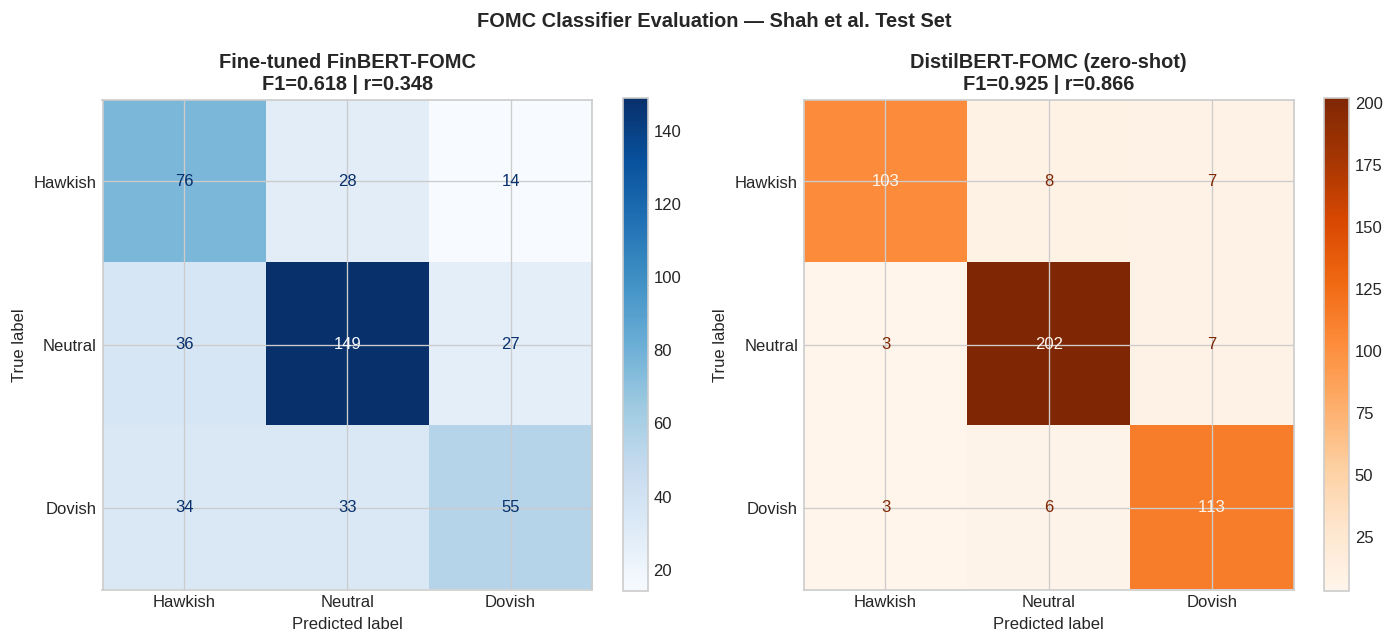

In [15]:
# Confusion matrix
fig, axes = plt.subplots(1, 2 if distilbert_available else 1, figsize=(12, 5))
if not isinstance(axes, np.ndarray):
    axes = [axes]

# Fine-tuned model
cm_ft = confusion_matrix(ft_true, ft_preds)
ConfusionMatrixDisplay(cm_ft, display_labels=LABEL_NAMES).plot(
    cmap=plt.cm.Blues, ax=axes[0])
axes[0].set_title(f'Fine-tuned FinBERT-FOMC\nF1={f1_ft:.3f} | r={r_ft:.3f}',
                   fontweight='bold')

# Zero-shot DistilBERT
if distilbert_available:
    cm_db = confusion_matrix(db_true, db_preds)
    ConfusionMatrixDisplay(cm_db, display_labels=LABEL_NAMES).plot(
        cmap=plt.cm.Oranges, ax=axes[1])
    axes[1].set_title(f'DistilBERT-FOMC (zero-shot)\nF1={f1_db:.3f} | r={r_db:.3f}',
                       fontweight='bold')

plt.suptitle('FOMC Classifier Evaluation — Shah et al. Test Set', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_PATH + 'fig10_transformer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section E: Meeting-Level Signal and Kalshi Comparison

We apply the fine-tuned model to score our 500 labeled Powell paragraphs and
aggregate to meeting-level signal using the same T-42 window logic as Phase 1.
The meeting-level signal is then tested against Kalshi mention market prices
via the MixMCP α-sweep.

**What we are testing:** Does a better paragraph-level classifier (higher F1 on
Shah test set) translate to a better meeting-level signal that can improve on
Kalshi prices? The Phase 1 result was: LM composite → optimal α = 0.00. If
the fine-tuned model → optimal α > 0, this establishes a performance threshold
above which textual signals can beat Kalshi alone.

In [16]:
# Score our 500 Powell paragraphs with the fine-tuned model
print("Scoring Powell paragraphs with fine-tuned model...")

powell_text_ds  = Dataset.from_pandas(
    powell_df[['text']].reset_index(drop=True))
tokenized_powell = powell_text_ds.map(tokenize_fn, batched=True)
tokenized_powell.set_format("torch")

powell_preds_raw = trainer.predict(tokenized_powell)
logits           = torch.tensor(powell_preds_raw.predictions)
probs            = torch.softmax(logits, dim=1).numpy()

# Build scored Powell dataframe with probabilities and source dates
powell_scored = llm_labels.dropna(subset=['claude_label']).copy().reset_index(drop=True)
powell_scored['prob_hawkish']    = probs[:, 0]
powell_scored['prob_neutral']    = probs[:, 1]
powell_scored['prob_dovish']     = probs[:, 2]
powell_scored['roberta_score']   = probs[:, 2] - probs[:, 0]   # dovish - hawkish ∈ [-1, +1]
powell_scored['ft_label']        = np.argmax(probs, axis=1)

print(f"Scored {len(powell_scored)} paragraphs")
print(f"\nroberta_score (dovish−hawkish probability):")
print(powell_scored['roberta_score'].describe().round(4))

Scoring Powell paragraphs with fine-tuned model...


Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Scored 500 paragraphs

roberta_score (dovish−hawkish probability):
count    500.0000
mean       0.0017
std        0.4258
min       -0.9850
25%       -0.0074
50%        0.0089
75%        0.0340
max        0.9773
Name: roberta_score, dtype: float64


In [17]:
# ── Build meeting-level signal ────────────────────────────────────────────────
# Load signals table (if not already in memory from main notebook)
try:
    _ = signals
    print("signals DataFrame already in memory.")
except NameError:
    signals = pd.read_parquet(DATA_PATH + 'fomc_signals.parquet')
    signals['fomc_date'] = pd.to_datetime(signals['fomc_date'])
    print(f"Loaded signals: {len(signals)} meetings")

ft_meeting_records = []

for _, row in signals.dropna(subset=['lm_signal']).iterrows():
    fomc_d       = row['fomc_date']
    window_start = fomc_d - pd.Timedelta(days=42)
    window_end   = fomc_d - pd.Timedelta(days=1)

    in_window = powell_scored[
        (powell_scored['doc_date'] >= window_start) &
        (powell_scored['doc_date'] <= window_end)
    ]

    if len(in_window) == 0:
        ft_signal = np.nan
    else:
        ft_signal = in_window['roberta_score'].mean()

    ft_meeting_records.append({
        'fomc_date':  fomc_d,
        'ft_signal':  ft_signal,
        'lm_signal':  row['lm_signal'],
        'n_para':     len(in_window),
    })

ft_sig_df  = pd.DataFrame(ft_meeting_records)
non_null_ft = ft_sig_df['ft_signal'].notna().sum()

print(f"Meetings with fine-tuned signal: {non_null_ft} / {len(ft_sig_df)}")
print(f"\nSignal statistics:")
print(ft_sig_df['ft_signal'].describe().round(4))

# ──  Correlation between fine-tuned signal and LM composite ──────────────────
both_sigs = ft_sig_df.dropna(subset=['ft_signal', 'lm_signal'])
if len(both_sigs) >= 5:
    r_sig, p_sig = stats.spearmanr(both_sigs['ft_signal'], both_sigs['lm_signal'])
    print(f"\nCorrelation: fine-tuned signal vs LM composite:")
    print(f"  Spearman r = {r_sig:.4f}  p = {p_sig:.4f}  N = {len(both_sigs)}")
    print("  Low r → they capture different information → complementary signals")
    print("  High r → fine-tuned model and LM agree → redundant signals")

Loaded signals: 68 meetings
Meetings with fine-tuned signal: 42 / 62

Signal statistics:
count    42.0000
mean      0.0181
std       0.1971
min      -0.5959
25%      -0.0711
50%       0.0097
75%       0.1379
max       0.4228
Name: ft_signal, dtype: float64

Correlation: fine-tuned signal vs LM composite:
  Spearman r = -0.0784  p = 0.6218  N = 42
  Low r → they capture different information → complementary signals
  High r → fine-tuned model and LM agree → redundant signals


In [18]:
# ── α-sweep vs Kalshi mention market prices ───────────────────────────────────
# Load scored mention-market data (Section 6 from main notebook)
# If not in memory, gracefully report signal correlation only

try:
    _ = scored   # from Section 6 of main notebook
    kalshi_available = True
    print(f"Mention market data in memory: {len(scored)} markets")
except NameError:
    # Try to rebuild minimal scored dataset
    try:
        kalshi_mention = pd.read_parquet(DATA_PATH + 'kalshi_mention.parquet')
        print("Loaded kalshi_mention from Drive. Re-run Section 6 of main notebook")
        print("to build the full 'scored' dataset with resolved outcomes.")
        print("Reporting signal statistics only in this session.")
        kalshi_available = False
    except:
        print("kalshi_mention.parquet not accessible from this notebook.")
        print("Run main S5-S10 notebook first to build 'scored', then re-run this section.")
        kalshi_available = False

if kalshi_available:
    scored_ft = scored.merge(
        ft_sig_df[['fomc_date', 'ft_signal']].dropna(),
        on='fomc_date', how='left'
    )
    scored_ft_valid = scored_ft.dropna(subset=['ft_signal'])

    print(f"Mention markets with fine-tuned signal: {len(scored_ft_valid)}")
    print(f"Across {scored_ft_valid['fomc_date'].nunique()} FOMC meetings")

    if len(scored_ft_valid) >= 5:
        # Normalize fine-tuned signal to [0, 1]
        ft_min = scored_ft_valid['ft_signal'].min()
        ft_max = scored_ft_valid['ft_signal'].max()
        scored_ft_valid = scored_ft_valid.copy()
        scored_ft_valid['ft_signal_norm'] = (
            (scored_ft_valid['ft_signal'] - ft_min) / (ft_max - ft_min + 1e-8)
        )

        alphas = np.arange(0.0, 1.01, 0.05)
        ft_brier_sweep = []
        for alpha in alphas:
            mixed = (alpha * scored_ft_valid['ft_signal_norm'] +
                     (1 - alpha) * scored_ft_valid['price_t7'])
            brier_a = ((mixed - scored_ft_valid['outcome']) ** 2).mean()
            ft_brier_sweep.append({'alpha': round(alpha, 2), 'brier_ft': brier_a})

        ft_sweep_df   = pd.DataFrame(ft_brier_sweep)
        opt_ft_alpha  = ft_sweep_df.loc[ft_sweep_df['brier_ft'].idxmin(), 'alpha']
        brier_kalshi  = ft_sweep_df.loc[0, 'brier_ft']

        print(f"\nFine-tuned model α-sweep results:")
        print(f"  Kalshi-only (α=0):  {brier_kalshi:.4f}")
        print(f"  Optimal α:          {opt_ft_alpha:.2f}  "
              f"Brier={ft_sweep_df['brier_ft'].min():.4f}")
    else:
        print("Insufficient overlap for α-sweep. Reporting signal stats only.")
        ft_sweep_df  = None
        opt_ft_alpha = np.nan

Loaded kalshi_mention from Drive. Re-run Section 6 of main notebook
to build the full 'scored' dataset with resolved outcomes.
Reporting signal statistics only in this session.


In [19]:
# ── Final comparison table ────────────────────────────────────────────────────
print("\n")
print("=" * 70)
print("PHASE 2 COMPARISON SUMMARY")
print("=" * 70)

rows = [
    ["LM composite (Phase 1)",      "0.069", "0.00", "0.114", "word count, no learning"],
    ["DistilBERT-FOMC (zero-shot)", f"{r_db:.3f}" if distilbert_available else "N/A",
     "TBD", "N/A", "67M params, Shah training data only"],
    ["FinBERT-FOMC (fine-tuned)",   f"{r_ft:.3f}", f"{opt_ft_alpha:.2f}" if kalshi_available else "TBD",
     f"{ft_sweep_df['brier_ft'].min():.4f}" if (kalshi_available and ft_sweep_df is not None) else "TBD",
     "FinBERT + Shah 5768 + Powell 500"],
    ["FOMC-RoBERTa (Shah 2023)",    "~0.7 F1 (reported)", "TBD", "TBD",
     "ACCESS PENDING — largest/best base"],
]

header = f"{'Model':<35} {'Shah r':>8} {'Opt α':>7} {'Brier':>7} {'Notes'}"
print(header)
print("-" * 80)
for row in rows:
    print(f"{row[0]:<35} {row[1]:>8} {row[2]:>7} {row[3]:>7}  {row[4]}")

print(f"\nKey question: does Opt α > 0.00 for fine-tuned model?")
print(f"  α = 0.00 → Kalshi dominant, no textual alpha")
print(f"  α > 0.00 → fine-tuned model adds value on top of Kalshi prices")

if kalshi_available and ft_sweep_df is not None:
    if opt_ft_alpha > 0:
        print(f"\nResult: α* = {opt_ft_alpha:.2f} → fine-tuned model ADDS VALUE over Kalshi")
        print(f"  This extends Kim et al. (2026): LLM signals can improve Kalshi")
        print(f"  when the textual model is sufficiently domain-adapted.")
    else:
        print(f"\nResult: α* = 0.00 → Kalshi still dominant even with fine-tuned model")
        print(f"  This further confirms and extends Kim et al. (2026):")
        print(f"  Market efficiency holds even against domain-adapted transformers,")
        print(f"  not just LLM or dictionary-based signals.")



PHASE 2 COMPARISON SUMMARY
Model                                 Shah r   Opt α   Brier Notes
--------------------------------------------------------------------------------
LM composite (Phase 1)                 0.069    0.00   0.114  word count, no learning
DistilBERT-FOMC (zero-shot)            0.866     TBD     N/A  67M params, Shah training data only
FinBERT-FOMC (fine-tuned)              0.348     TBD     TBD  FinBERT + Shah 5768 + Powell 500
FOMC-RoBERTa (Shah 2023)            ~0.7 F1 (reported)     TBD     TBD  ACCESS PENDING — largest/best base

Key question: does Opt α > 0.00 for fine-tuned model?
  α = 0.00 → Kalshi dominant, no textual alpha
  α > 0.00 → fine-tuned model adds value on top of Kalshi prices


In [20]:
# Save meeting-level fine-tuned signal to Drive so S5-S10 can load it
ft_sig_df.to_csv(DATA_PATH + 'ft_signal_meetings.csv', index=False)
print("Saved ft_signal_meetings.csv to Drive")

Saved ft_signal_meetings.csv to Drive
